# BÀI TẬP CHƯƠNG 4 - DEEP LEARNING VỚI KERAS

**Chủ đề:** Classification and Regression  
**Ngôn ngữ:** Python + TensorFlow/Keras  
**Mục tiêu:** Thực hành các bài toán tiêu biểu trong Chương 4:
- Phân loại nhị phân với IMDB
- Phân loại đa lớp nhỏ với Iris
- Phân loại đa lớp với Reuters
- Hồi quy với Boston Housing

---

## Yêu cầu chung
1. Hoàn thành các phần còn thiếu trong các ô code.
2. Chạy từng phần theo đúng thứ tự.
3. Trả lời ngắn gọn các câu hỏi thảo luận ở cuối mỗi bài.
4. Không sửa tên biến nếu không cần thiết.

---

## Chuẩn đầu ra
Sau khi hoàn thành notebook này, sinh viên có thể:
- Nạp và tiền xử lý dữ liệu cho bài toán phân loại và hồi quy.
- Xây dựng mô hình phân loại nhị phân, đa lớp và hồi quy bằng Keras.
- Chọn activation, loss, metric phù hợp với từng bài toán.
- Quan sát validation loss / validation accuracy để phát hiện overfitting.
- Chuẩn hóa đặc trưng số cho các bài toán cần thiết.
- Áp dụng K-fold validation khi dữ liệu ít.


In [1]:
# Cài đặt / import thư viện cần thiết
import numpy as np
import matplotlib.pyplot as plt

from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import imdb, reuters, boston_housing

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

print('TensorFlow / Keras / scikit-learn đã sẵn sàng!')


2026-04-19 19:03:43.840278: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-19 19:03:43.914071: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-19 19:03:45.350625: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow / Keras / scikit-learn đã sẵn sàng!


# PHẦN 1 - IMDB: PHÂN LOẠI NHỊ PHÂN

Trong phần này, bạn sẽ xây dựng mô hình phân loại cảm xúc của review phim: **tích cực / tiêu cực**.

## Bài 1.1 - Nạp dữ liệu IMDB

**Yêu cầu:**
- Nạp dữ liệu IMDB với 10,000 từ phổ biến nhất.
- In ra số lượng mẫu train và test.
- In thử độ dài của một sample đầu tiên.

In [2]:
# TODO: Nạp dữ liệu IMDB với num_words=10000
num_words = 10000

# TODO: In kích thước tập train và test
(train_data, train_labels), (test_data, test_labels) = imdb.load_data(num_words=num_words)

# TODO: In độ dài sample đầu tiên của train_data
print('Số mẫu train:', len(train_data))
print('Số mẫu test :', len(test_data))
print('Ví dụ review đầu tiên (dạng số nguyên):', train_data[0][:20])
print('Nhãn của review đầu tiên:', train_labels[0])

Số mẫu train: 25000
Số mẫu test : 25000
Ví dụ review đầu tiên (dạng số nguyên): [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25]
Nhãn của review đầu tiên: 1


## Bài 1.2 - Vector hóa dữ liệu

**Yêu cầu:**
- Viết hàm `vectorize_sequences()` để biến mỗi review thành vector nhị phân kích thước 10,000.
- Vector hóa `train_data` và `test_data`.
- Chuyển nhãn sang `float32`.

In [3]:
def vectorize_sequences(sequences, dimension=10000):
    # TODO: Tạo ma trận toàn số 0 với shape phù hợp
    results = np.zeros((len(sequences), dimension))
    # TODO: Duyệt từng sequence và gán 1.0 tại các vị trí từ xuất hiện
    for i, sequence in enumerate(sequences):
        results[i, sequence] = 1.0
    return results

# TODO: Vector hóa train_data và test_data
x_train = vectorize_sequences(train_data, num_words)
x_test = vectorize_sequences(test_data, num_words)

# TODO: Chuyển train_labels, test_labels sang float32
y_train = np.asarray(train_labels).astype('float32')
y_test = np.asarray(test_labels).astype('float32')

# TODO: In shape của x_train và x_test
print('Shape x_train:', x_train.shape)
print('Shape x_test :', x_test.shape)


Shape x_train: (25000, 10000)
Shape x_test : (25000, 10000)


## Bài 1.3 - Tạo tập validation

**Yêu cầu:**
- Lấy 8,000 mẫu đầu của tập train làm validation.
- Phần còn lại dùng để train.
- Tạo các biến: `x_val`, `partial_x_train`, `y_val`, `partial_y_train`.

In [4]:
# TODO: Tách validation set và partial train set
# Gợi ý:
# x_val = ...
# partial_x_train = ...
# y_val = ...
# partial_y_train = ...

x_val = x_train[:10000]
partial_x_train = x_train[10000:]

y_val = y_train[:10000]
partial_y_train = y_train[10000:]

# TODO: In shape để kiểm tra
print('Shape partial_x_train:', partial_x_train.shape)
print('Shape x_val          :', x_val.shape)

Shape partial_x_train: (15000, 10000)
Shape x_val          : (10000, 10000)


## Bài 1.4 - Xây dựng mô hình IMDB

**Yêu cầu:**
- Tạo mô hình `Sequential` gồm:
  - Dense(16, relu)
  - Dense(16, relu)
  - Output layer: tự khai báo cho phù hợp
- Compile với:
  - optimizer = `rmsprop`
  - loss = `binary_crossentropy`
  - metrics = `accuracy`

In [6]:
# TODO: Tạo mô hình imdb_model
imdb_model = keras.Sequential([    
    #layers.Dense(16, activation='relu', input_shape=(10000,)),
    layers.Dense(16, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

# TODO: Compile mô hình
imdb_model.compile(
    optimizer='rmsprop',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# TODO: Hiển thị summary

imdb_model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Bài 1.5 - Huấn luyện mô hình và theo dõi validation

**Yêu cầu:**
- Train mô hình trong 20 epochs.
- batch_size = 256.
- Lưu kết quả vào biến `history`.

In [7]:
# TODO: Train mô hình với validation_data=(x_val, y_val)
# history = ...
history = imdb_model.fit(
    partial_x_train,
    partial_y_train,
    epochs=20,
    batch_size=256,
    validation_data=(x_val, y_val),
    verbose=1
)

Epoch 1/20


2026-04-16 16:26:07.515886: I external/local_xla/xla/service/service.cc:163] XLA service 0x7b0bcc0194c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-04-16 16:26:07.515901: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA RTX A2000 8GB Laptop GPU, Compute Capability 8.6
2026-04-16 16:26:07.539748: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-04-16 16:26:07.643634: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91002
2026-04-16 16:26:07.936537: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_289', 8 bytes spill stores, 8 bytes spill loads



40/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7192 - loss: 0.5800

I0000 00:00:1776331568.770685  147693 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


58/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7484 - loss: 0.5450

2026-04-16 16:26:09.486545: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_47', 12 bytes spill stores, 12 bytes spill loads



59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7497 - loss: 0.5433

2026-04-16 16:26:11.022314: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_19', 4 bytes spill stores, 4 bytes spill loads

2026-04-16 16:26:11.030508: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_19', 4 bytes spill stores, 4 bytes spill loads



59/59 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - accuracy: 0.8242 - loss: 0.4463 - val_accuracy: 0.8705 - val_loss: 0.3393
Epoch 2/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9131 - loss: 0.2487 - val_accuracy: 0.8875 - val_loss: 0.2833
Epoch 3/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9375 - loss: 0.1812 - val_accuracy: 0.8844 - val_loss: 0.2852
Epoch 4/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9510 - loss: 0.1410 - val_accuracy: 0.8835 - val_loss: 0.3099
Epoch 5/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9642 - loss: 0.1123 - val_accuracy: 0.8842 - val_loss: 0.3127
Epoch 6/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9730 - loss: 0.0883 - val_accuracy: 0.8816 - val_loss: 0.3433
Epoch 7/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9799 - loss: 0.0702 - val_accuracy: 0.8750 - val_loss: 0.3710
Epoch 8/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9845 - loss: 0.0548 - val_accuracy: 0.8767 - val_loss: 0.3991
Ep

## Bài 1.6 - Vẽ biểu đồ loss

**Yêu cầu:**
- Lấy `loss` và `val_loss` từ `history.history`.
- Tạo danh sách `epochs`.
- Vẽ 2 đường/chuỗi điểm:
  - Training loss
  - Validation loss
- Quan sát biểu đồ và cho biết: Nên chọn bao nhiêu epochs là hợp lý? Lý do?

  Ở đây chọn khoảng 4-5 epochs là hợp lý vì sau đó validation loss bắt đầu tăng lên, cho thấy mô hình bắt đầu overfitting trên tập train.

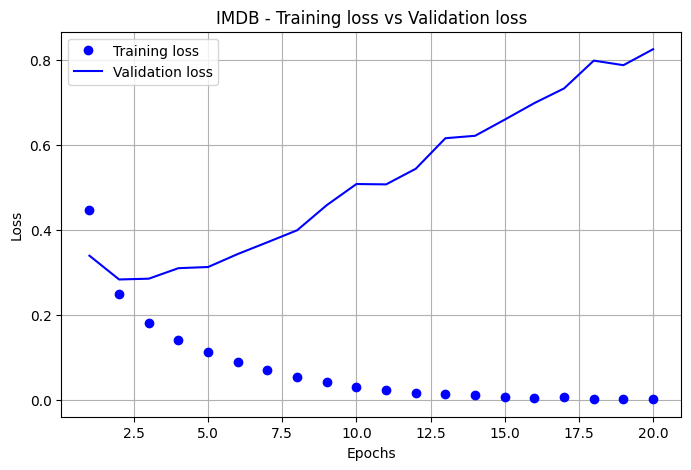

In [8]:
# TODO: Lấy loss và val_loss từ history
history_dict = history.history
loss_values = history_dict['loss']
val_loss_values = history_dict['val_loss']

# TODO: Tạo biến epochs
epochs = range(1, len(loss_values) + 1)

# TODO: Vẽ biểu đồ training loss và validation loss
# Gợi ý:
# plt.plot(epochs, loss_values, 'bo', label='Training loss')
# plt.plot(epochs, val_loss_values, 'b', label='Validation loss')
# plt.legend()
# plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs, loss_values, 'bo', label='Training loss')
plt.plot(epochs, val_loss_values, 'b', label='Validation loss')
plt.title('IMDB - Training loss vs Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


## Bài 1.7 - Huấn luyện mô hình cuối cùng

**Yêu cầu:**
- Tạo lại một mô hình mới cùng kiến trúc.
- Huấn luyện với số epoch phù hợp hơn dựa trên biểu đồ validation loss.
- Đánh giá trên test set.

In [9]:
# TODO: Tạo lại mô hình imdb_final_model
imdb_final_model = keras.Sequential([
    layers.Dense(16, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

# TODO: Compile mô hình
imdb_final_model.compile(
    optimizer='rmsprop',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# TODO: Train lại mô hình trên toàn bộ x_train và y_train
imdb_final_model.fit(
    partial_x_train,
    partial_y_train,
    epochs=3,
    batch_size=256,
    validation_data=(x_val, y_val),
    verbose=1
)

# TODO: Đánh giá trên x_test và y_test\
imdb_results = imdb_final_model.evaluate(x_test, y_test)

# TODO: In kết quả test
print('Test loss    :', imdb_results[0])
print('Test accuracy:', imdb_results[1])

Epoch 1/3
59/59 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.8139 - loss: 0.4662 - val_accuracy: 0.8807 - val_loss: 0.3285
Epoch 2/3
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9119 - loss: 0.2545 - val_accuracy: 0.8916 - val_loss: 0.2782
Epoch 3/3
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9333 - loss: 0.1853 - val_accuracy: 0.8790 - val_loss: 0.2997


2026-04-16 16:27:00.777978: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_19', 4 bytes spill stores, 4 bytes spill loads

2026-04-16 16:27:00.818896: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_19', 4 bytes spill stores, 4 bytes spill loads

2026-04-16 16:27:00.833042: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_19', 4 bytes spill stores, 4 bytes spill loads

2026-04-16 16:27:00.861191: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_19', 4 bytes spill stores, 4 bytes spill loads



743/782 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8697 - loss: 0.3192

2026-04-16 16:27:02.342208: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_19', 8 bytes spill stores, 8 bytes spill loads



782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8704 - loss: 0.3201
Test loss    : 0.3200664520263672
Test accuracy: 0.8703600168228149


## Câu hỏi thảo luận - IMDB

**1. Vì sao lớp cuối dùng `sigmoid` thay vì `softmax`?**

    Vì đây là bài toán phân loại nhị phân (binary classification), chỉ có hai lớp (positive và negative). Hàm kích hoạt `sigmoid` sẽ trả về giá trị trong khoảng [0, 1], biểu thị xác suất của một mẫu thuộc về lớp positive. Trong khi đó, `softmax` thường được sử dụng cho bài toán phân loại đa lớp (multi-class classification) và sẽ trả về một vector xác suất cho tất cả các lớp, mà ở đây không cần thiết vì chỉ có hai lớp.

**2. Vì sao bài toán này dùng `binary_crossentropy`?**

    Bài toán này dùng `binary_crossentropy` vì đây là hàm mất mát phù hợp cho bài toán phân loại nhị phân. `binary_crossentropy` đo lường sự khác biệt giữa hai phân phối xác suất: phân phối thực tế (ground truth) và phân phối dự đoán của mô hình. Nó sẽ phạt nặng hơn khi mô hình dự đoán sai lớp, giúp mô hình học tốt hơn trong việc phân biệt giữa hai lớp.

**3. Dấu hiệu nào trên biểu đồ cho thấy mô hình bắt đầu overfit?**

    Dấu hiệu cho thấy mô hình bắt đầu overfit là khi đường loss của training tiếp tục giảm trong khi đường loss của validation bắt đầu tăng hoặc không giảm nữa. Điều này cho thấy mô hình đang học quá kỹ các mẫu trong tập training và không thể tổng quát hóa tốt trên dữ liệu unseen (validation set).

**4. Nếu tăng số neuron ở các lớp ẩn quá nhiều thì điều gì có thể xảy ra?**

    Nếu tăng số neuron ở các lớp ẩn quá nhiều, mô hình có thể trở nên quá phức tạp và dễ bị overfit. Điều này có nghĩa là mô hình sẽ học quá kỹ các chi tiết của dữ liệu training, bao gồm cả nhiễu (noise), và sẽ không tổng quát hóa tốt trên dữ liệu mới (validation/test set). Kết quả là, mặc dù mô hình có thể đạt được độ chính xác cao trên tập training, nhưng hiệu suất trên tập validation hoặc test có thể giảm đáng kể.

# PHẦN 2 - IRIS: PHÂN LOẠI ĐA LỚP NHỎ

Trong phần này, bạn sẽ xây dựng mô hình phân loại 3 loài hoa Iris dựa trên 4 đặc trưng số.

## Bài 2.1 - Nạp dữ liệu Iris

**Yêu cầu:**
- Nạp bộ dữ liệu Iris bằng `load_iris()`.
- In shape của dữ liệu và nhãn.
- In tên các lớp.

In [1]:
# TODO: Nạp bộ dữ liệu Iris
from sklearn.datasets import load_iris
iris = load_iris()

# TODO: Tạo biến data và targets
x = iris.data
y = iris.target

# TODO: In shape của data, targets
print("Shape of data:", x.shape)
print("Shape of targets:", y.shape)

# TODO: In tên các lớp
print("Tên các lớp:", iris.target_names)

Shape of data: (150, 4)
Shape of targets: (150,)
Tên các lớp: ['setosa' 'versicolor' 'virginica']


## Bài 2.2 - Chia train/test và chuẩn hóa dữ liệu

**Yêu cầu:**
- Chia dữ liệu thành train/test theo tỉ lệ 80/20.
- Dùng `random_state=42`.
- Tính mean/std từ train set.
- Chuẩn hóa cả train và test bằng mean/std của train.

In [4]:
# TODO: Chia train/test cho Iris
x_train_iris, x_test_iris, y_train_iris, y_test_iris = train_test_split(x, y, test_size=0.2, random_state=42)

# TODO: Tính mean từ x_train_iris
mean_train = x_train_iris.mean(axis=0)

# TODO: Chuẩn hóa x_train_iris và x_test_iris
x_train_iris = (x_train_iris - mean_train) / x_train_iris.std(axis=0)
x_test_iris = (x_test_iris - mean_train) / x_train_iris.std(axis=0)

# TODO: Kiểm tra mean/std của x_train_iris sau chuẩn hóa
print("Mean of x_train_iris after normalization:", x_train_iris.mean(axis=0))
print("Std of x_train_iris after normalization:", x_train_iris.std(axis=0))

Mean of x_train_iris after normalization: [ 1.71344420e-15 -1.66579713e-15 -2.23894977e-16 -5.73615229e-17]
Std of x_train_iris after normalization: [1. 1. 1. 1.]


## Bài 2.3 - One-hot hóa nhãn Iris

**Yêu cầu:**
- Dùng `keras.utils.to_categorical()` để one-hot hóa nhãn train/test.
- In shape của nhãn sau one-hot.

In [5]:
# TODO: One-hot hóa y_train_iris và y_test_iris
one_hot_y_train_iris = keras.utils.to_categorical(y_train_iris)
one_hot_y_test_iris = keras.utils.to_categorical(y_test_iris)

# TODO: In shape của nhãn sau one-hot
print("Shape of one-hot y_train_iris:", one_hot_y_train_iris.shape)
print("Shape of one-hot y_test_iris :", one_hot_y_test_iris.shape)

Shape of one-hot y_train_iris: (120, 3)
Shape of one-hot y_test_iris : (30, 3)


## Bài 2.4 - Tạo validation set cho Iris

**Yêu cầu:**
- Lấy 20% từ tập train làm validation.
- Tạo các biến:
  - `x_val_iris`, `partial_x_train_iris`
  - `y_val_iris`, `partial_y_train_iris`

In [6]:
# TODO: Tự tách validation set từ x_train_iris và y_train_iris_cat
x_val_iris = x_train_iris[:20]
y_val_iris = one_hot_y_train_iris[:20]

partial_x_train_iris = x_train_iris[20:]
partial_y_train_iris = one_hot_y_train_iris[20:]
# TODO: In shape để kiểm tra
print('Shape partial_x_train_iris:', partial_x_train_iris.shape)
print('Shape x_val_iris          :', x_val_iris.shape)
print('Shape partial_y_train_iris:', partial_y_train_iris.shape)
print('Shape y_val_iris          :', y_val_iris.shape)


Shape partial_x_train_iris: (100, 4)
Shape x_val_iris          : (20, 4)
Shape partial_y_train_iris: (100, 3)
Shape y_val_iris          : (20, 3)


## Bài 2.5 - Xây dựng mô hình Iris

**Yêu cầu:**
- Tạo mô hình gồm:
  - Dense(16, relu)
  - Dense(16, relu)
  - Output layer: khai báo cho phù hợp
- Compile với:
  - optimizer = `rmsprop`
  - loss = `categorical_crossentropy`
  - metrics = `accuracy`

In [7]:
# TODO: Tạo mô hình iris_model
iris_model = keras.Sequential([
    layers.Dense(16, activation='relu', input_shape=(4,)),
    layers.Dense(16, activation='relu'),
    layers.Dense(3, activation='softmax')
])

# TODO: Compile mô hình
iris_model.compile(
    optimizer='rmsprop',
    loss='categorical_crossentropy',
    metrics=['accuracy']
) 

# TODO: Hiển thị summary
iris_model.summary()


/home/zhu/micromamba/lib/python3.12/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1776598666.330554   30845 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6203 MB memory:  -> device: 0, name: NVIDIA RTX A2000 8GB Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 403 (1.57 KB)

 Trainable params: 403 (1.57 KB)

 Non-trainable params: 0 (0.00 B)

## Bài 2.6 - Huấn luyện và theo dõi validation

**Yêu cầu:**
- Train mô hình 50 epochs.
- batch_size = 16.
- Theo dõi validation accuracy và validation loss.

In [8]:
# TODO: Train mô hình Iris
history_iris = iris_model.fit(
    partial_x_train_iris,
    partial_y_train_iris,
    epochs=50,
    batch_size=16,
    validation_data=(x_val_iris, y_val_iris)
)

Epoch 1/50


2026-04-19 18:38:46.293632: I external/local_xla/xla/service/service.cc:163] XLA service 0x7dd734016e30 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-04-19 18:38:46.293652: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA RTX A2000 8GB Laptop GPU, Compute Capability 8.6
2026-04-19 18:38:46.360421: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-04-19 18:38:46.550371: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91002


1/7 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - accuracy: 0.0625 - loss: 1.1858

I0000 00:00:1776598727.846995   36852 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 417ms/step - accuracy: 0.2100 - loss: 1.1367 - val_accuracy: 0.2500 - val_loss: 1.0919
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.3900 - loss: 1.0679 - val_accuracy: 0.3500 - val_loss: 1.0441
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.4800 - loss: 1.0200 - val_accuracy: 0.5000 - val_loss: 1.0038
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.5600 - loss: 0.9790 - val_accuracy: 0.7500 - val_loss: 0.9660
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.6900 - loss: 0.9421 - val_accuracy: 0.7500 - val_loss: 0.9237
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7600 - loss: 0.9016 - val_accuracy: 0.7500 - val_loss: 0.8855
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.7700 - loss: 0.8628 - val_accuracy: 0.7500 - val_loss: 0.8484
Epoch 8/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.7800 - loss: 0.8263 - val_accuracy: 0.7500 - val_loss: 0.8171
Epoch 9/50

## Bài 2.7 - Vẽ biểu đồ accuracy của Iris

**Yêu cầu:**
- Lấy `accuracy` và `val_accuracy` từ `history_iris.history`.
- Vẽ biểu đồ so sánh train accuracy và validation accuracy.
- Quan sát biểu đồ và cho biết: Nên chọn bao nhiêu epochs là hợp lý? Lý do?

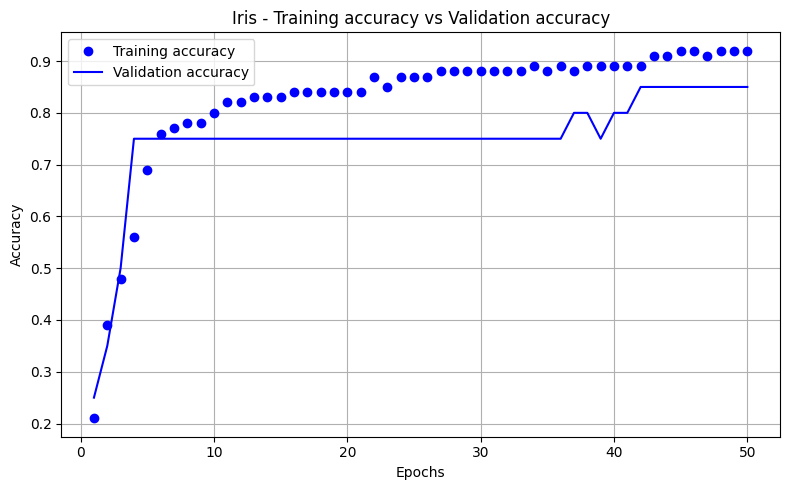

In [11]:
# TODO: Trích xuất accuracy và val_accuracy
accuracy = history_iris.history['accuracy']
val_accuracy = history_iris.history['val_accuracy']

# TODO: Tạo epochs_iris
epochs_iris = range(1, len(accuracy) + 1)

# TODO: Vẽ biểu đồ accuracy
plt.figure(figsize=(8, 5))
plt.plot(epochs_iris, accuracy, 'bo', label='Training accuracy')
plt.plot(epochs_iris, val_accuracy, 'b', label='Validation accuracy')
plt.title('Iris - Training accuracy vs Validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.tight_layout()
plt.legend()
plt.grid(True)
plt.show()


## Bài 2.8 - Đánh giá trên test set

**Yêu cầu:**
- Tạo lại mô hình Iris mới.
- Train với số epoch hợp lý hơn nếu cần.
- Đánh giá trên test set.

In [16]:
# TODO: Tạo iris_final_model
iris_final_model = keras.Sequential([
    layers.Dense(16, activation='relu', input_shape=(4,)),
    layers.Dense(16, activation='relu'),
    layers.Dense(3, activation='softmax')
])

# TODO: Compile mô hình
iris_final_model.compile(
    optimizer='rmsprop',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# TODO: Train trên toàn bộ x_train_iris và y_train_iris_cat
x_train_iris_full = x_train_iris
y_train_iris_full = one_hot_y_train_iris

# TODO: Train mô hình
iris_final_model.fit(
    x_train_iris_full, 
    y_train_iris_full, 
    epochs=10, #10 - 42 
    batch_size=16, 
    validation_split=0.2
)

# TODO: Đánh giá trên x_test_iris và y_test_iris_cat
test_loss_iris, test_acc_iris = iris_final_model.evaluate(x_test_iris, one_hot_y_test_iris, verbose=0)

# TODO: In test_loss_iris và test_acc_iris
print(f"Test loss: {test_loss_iris}")
print(f"Test accuracy: {test_acc_iris}")


Epoch 1/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 223ms/step - accuracy: 0.2604 - loss: 1.0971 - val_accuracy: 0.6250 - val_loss: 1.0189
Epoch 2/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.5312 - loss: 0.9999 - val_accuracy: 0.6250 - val_loss: 0.9567
Epoch 3/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6146 - loss: 0.9322 - val_accuracy: 0.6250 - val_loss: 0.9035
Epoch 4/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.6875 - loss: 0.8706 - val_accuracy: 0.6667 - val_loss: 0.8537
Epoch 5/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.7083 - loss: 0.8159 - val_accuracy: 0.7083 - val_loss: 0.8100
Epoch 6/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7812 - loss: 0.7644 - val_accuracy: 0.7083 - val_loss: 0.7703
Epoch 7/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.7917 - loss: 0.7187 - val_accuracy: 0.7500 - val_loss: 0.7324
Epoch 8/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.8229 - loss: 0.6757 - val_accuracy: 0.7917 - val_loss: 0.6970

## Câu hỏi thảo luận - Iris

1. Vì sao bài toán Iris là bài toán phân loại đa lớp?

    Vì bài toán Iris có 3 lớp (setosa, versicolor, virginica) nên đây là bài toán phân loại đa lớp. Mỗi mẫu dữ liệu sẽ được phân loại vào một trong ba lớp này, không phải chỉ hai lớp như trong bài toán phân loại nhị phân.

2. Vì sao lớp cuối nên dùng `softmax`?

    Vì `softmax` sẽ chuyển đổi đầu ra của lớp cuối thành xác suất cho mỗi lớp, đảm bảo rằng tổng xác suất của tất cả các lớp bằng 1. Điều này rất quan trọng trong bài toán phân loại đa lớp, giúp mô hình dự đoán được lớp nào có xác suất cao nhất.

3. Vì sao số neuron ở lớp cuối phải là 3?

    Vì bài toán Iris có 3 lớp (setosa, versicolor, virginica), nên lớp cuối phải có 3 neuron để đại diện cho mỗi lớp.

4. Nếu không chuẩn hóa dữ liệu đầu vào thì mô hình có thể gặp khó khăn gì?
    
    Nếu không chuẩn hóa dữ liệu đầu vào, các đặc trưng có độ lớn khác nhau sẽ ảnh hưởng đến quá trình huấn luyện của mô hình, khiến mô hình khó hội tụ và có thể dẫn đến kết quả kém.


# PHẦN 3 - REUTERS: PHÂN LOẠI ĐA LỚP

Trong phần này, bạn sẽ phân loại bản tin Reuters vào nhiều chủ đề khác nhau.

## Bài 3.1 - Nạp dữ liệu Reuters

**Yêu cầu:**
- Nạp dữ liệu Reuters với 10,000 từ phổ biến nhất.
- In số lượng mẫu train và test.
- In số lượng lớp khác nhau.

In [11]:
# TODO: Nạp dữ liệu Reuters
num_words = 10000
(train_data, train_labels), (test_data, test_labels) = reuters.load_data(num_words=num_words)

# TODO: In số lượng mẫu train và test
print(f"Number of training samples: {len(train_data)}")
print(f"Number of test samples    : {len(test_data)}")

# TODO: In số lượng lớp khác nhau trong train_labels
print(f"Number of unique classes in train_labels: {len(set(train_labels))}")


Number of training samples: 8982
Number of test samples    : 2246
Number of unique classes in train_labels: 46


## Bài 3.2 - Vector hóa dữ liệu và one-hot labels

**Yêu cầu:**
- Dùng lại ý tưởng vector hóa sequence như bài IMDB.
- Viết hàm `to_one_hot()` để one-hot hóa nhãn.
- Tạo `x_train`, `x_test`, `one_hot_train_labels`, `one_hot_test_labels`.

In [12]:
def vectorize_sequences(sequences, dimension=10000):
    # TODO
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        results[i, sequence] = 1
    return results

def to_one_hot(labels, dimension=46):
    # TODO: Tạo ma trận toàn số 0
    results = np.zeros((len(labels), dimension))
    for i, label in enumerate(labels):
    # TODO: Gán 1.0 tại vị trí lớp đúng
        results[i, label] = 1.0
    return results

# TODO: Vector hóa x_train, x_test
x_train = vectorize_sequences(train_data, num_words)
x_test = vectorize_sequences(test_data, num_words)

# TODO: One-hot hóa nhãn train và test
y_train = to_one_hot(train_labels, dimension=46)
y_test = to_one_hot(test_labels, dimension=46)

# TODO: In shape để kiểm tra
print("Shape of x_train:", x_train.shape)
print("Shape of x_test:", x_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of x_train: (8982, 10000)
Shape of x_test: (2246, 10000)
Shape of y_train: (8982, 46)
Shape of y_test: (2246, 46)


## Bài 3.3 - Tạo validation set cho Reuters

**Yêu cầu:**
- Lấy 1,000 mẫu đầu làm validation.
- Tạo các biến train/validation tương ứng.

In [13]:
# TODO: Tách validation set cho Reuters
x_val_reuters = x_train[:1000]
partial_x_train_reuters = x_train[1000:]
y_val_reuters = y_train[:1000]
partial_y_train_reuters = y_train[1000:]

# TODO: In shape các tập dữ liệu vừa tạo
print("Shape of x_val_reuters:", x_val_reuters.shape)
print("Shape of partial_x_train_reuters:", partial_x_train_reuters.shape)
print("Shape of y_val_reuters:", y_val_reuters.shape)
print("Shape of partial_y_train_reuters:", partial_y_train_reuters.shape)

Shape of x_val_reuters: (1000, 10000)
Shape of partial_x_train_reuters: (7982, 10000)
Shape of y_val_reuters: (1000, 46)
Shape of partial_y_train_reuters: (7982, 46)


## Bài 3.4 - Xây dựng mô hình Reuters

**Yêu cầu:**
- Tạo mô hình gồm:
  - Dense(64, relu)
  - Dense(64, relu)
  - Output layer: tự khai báo cho phù hợp
- Compile với:
  - optimizer = `rmsprop`
  - loss = `categorical_crossentropy`
  - metrics = `accuracy`

In [5]:
# TODO: Tạo mô hình reuters_model

reuters_model = models.Sequential([
    layers.Dense(64, activation='relu', input_shape=(10000,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(46, activation='softmax')
])

# TODO: Compile mô hình
reuters_model.compile(
    optimizer='rmsprop',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# TODO: model.summary()
reuters_model.summary()


/home/zhu/micromamba/lib/python3.12/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1776600241.897960   81082 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 6203 MB memory:  -> device: 0, name: NVIDIA RTX A2000 8GB Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │       640,064 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 46)             │         2,990 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 647,214 (2.47 MB)

 Trainable params: 647,214 (2.47 MB)

 Non-trainable params: 0 (0.00 B)

## Bài 3.5 - Train và quan sát overfitting

**Yêu cầu:**
- Train mô hình trong 20 epochs.
- batch_size = 256.
- validation_data = (x_val, y_val).
- Lưu vào `history`.

In [6]:
# TODO: Train mô hình Reuters
history = reuters_model.fit(
    partial_x_train_reuters,
    partial_y_train_reuters,
    epochs=20,
    batch_size=256,
    validation_data=(x_val_reuters, y_val_reuters)
)

Epoch 1/20


2026-04-19 19:04:19.753644: I external/local_xla/xla/service/service.cc:163] XLA service 0x7a928c004830 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-04-19 19:04:19.753670: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): NVIDIA RTX A2000 8GB Laptop GPU, Compute Capability 8.6
2026-04-19 19:04:19.780486: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-04-19 19:04:19.896527: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91002
2026-04-19 19:04:19.923294: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-19 19:04:19.923

15/32 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3139 - loss: 3.2704

I0000 00:00:1776600267.765591   82014 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


29/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.3990 - loss: 2.8836

2026-04-19 19:04:28.224093: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-19 19:04:28.224124: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-19 19:04:28.224158: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-19 19:04:28.224199: I external/l

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step - accuracy: 0.4125 - loss: 2.8202

2026-04-19 19:04:34.380730: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-19 19:04:34.380766: I external/local_xla/xla/service/gpu/autotuning/dot_search_space.cc:208] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
2026-04-19 19:04:35.051298: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_66', 8 bytes spill stores, 8 bytes spill loads

2026-04-19 19:04:35.604026: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Reg

32/32 ━━━━━━━━━━━━━━━━━━━━ 18s 302ms/step - accuracy: 0.5450 - loss: 2.1963 - val_accuracy: 0.6630 - val_loss: 1.4560
Epoch 2/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7360 - loss: 1.2159 - val_accuracy: 0.7180 - val_loss: 1.2216
Epoch 3/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.7955 - loss: 0.9212 - val_accuracy: 0.7390 - val_loss: 1.0912
Epoch 4/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8395 - loss: 0.7107 - val_accuracy: 0.7950 - val_loss: 0.9697
Epoch 5/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.8796 - loss: 0.5518 - val_accuracy: 0.8010 - val_loss: 0.9094
Epoch 6/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.9087 - loss: 0.4298 - val_accuracy: 0.7990 - val_loss: 0.9151
Epoch 7/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9265 - loss: 0.3442 - val_accuracy: 0.8140 - val_loss: 0.9027
Epoch 8/20
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9380 - loss: 0.2834 - val_accuracy: 0.8230 - val_loss: 

## Bài 3.6 - Vẽ biểu đồ loss / accuracy

**Yêu cầu:**
- Vẽ biểu đồ training loss và validation loss.
- Vẽ biểu đồ training accuracy và validation accuracy.
- Quan sát biểu đồ và cho biết: Nên chọn bao nhiêu epochs là hợp lý? Lý do?

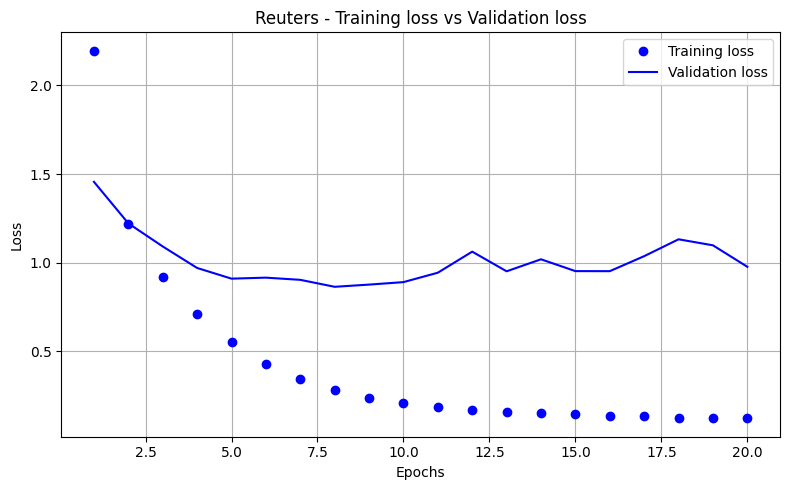

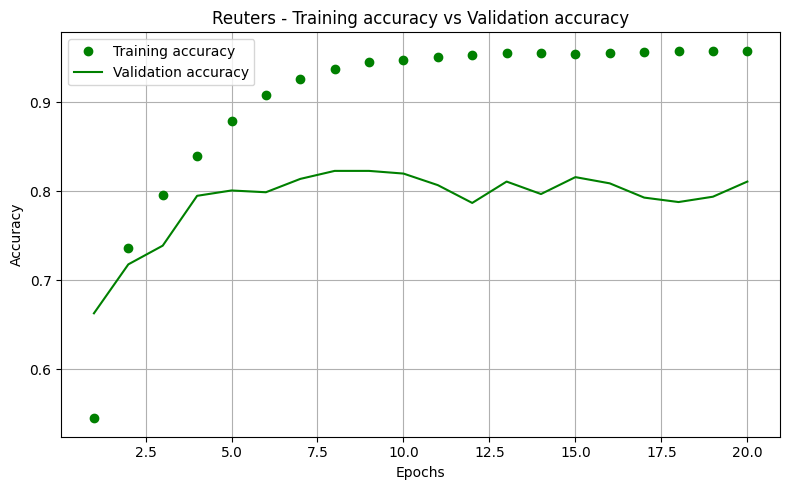

In [8]:
# TODO: Trích xuất loss, val_loss, accuracy, val_accuracy từ history.history
val_loss = history.history['val_loss']
loss = history.history['loss']
accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']
epochs = range(1, len(loss) + 1)

# TODO: Vẽ biểu đồ loss
plt.figure(figsize=(8, 5))
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Reuters - Training loss vs Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.grid(True)
plt.show()

# TODO: Vẽ biểu đồ accuracy
plt.figure(figsize=(8, 5))
plt.plot(epochs, accuracy, 'go', label='Training accuracy')
plt.plot(epochs, val_accuracy, 'g', label='Validation accuracy')
plt.title('Reuters - Training accuracy vs Validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.grid(True)
plt.show()


## Bài 3.7 - Huấn luyện mô hình cuối cùng

**Yêu cầu:**
- Tạo lại mô hình mới cùng kiến trúc.
- Huấn luyện với số epoch phù hợp hơn.
- Đánh giá trên test set.

In [ ]:
# TODO: Tạo reuters_final_model
reuters_final_model = models.Sequential([
    layers.Dense(64, activation='relu', input_shape=(10000,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(46, activation='softmax')
])

# TODO: Compile mô hình
reuters_final_model.compile(
    optimizer='rmsprop',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# TODO: Train lại trên toàn bộ x_train và one_hot_train_labels
reuters_final_model.fit(
    x_train,
    y_train,
    epochs=8,
    batch_size=256,
    validation_data=(x_val_reuters, y_val_reuters)
)

# TODO: Đánh giá trên test set

test_loss, test_accuracy = reuters_final_model.evaluate(x_test, y_test)

# TODO: In test_loss, test_accuracy
print(f"Test Loss: {test_loss}")
print(f"Test Accuracy: {test_accuracy}")


Epoch 1/8
36/36 ━━━━━━━━━━━━━━━━━━━━ 6s 97ms/step - accuracy: 0.5949 - loss: 2.0340 - val_accuracy: 0.6920 - val_loss: 1.2758
Epoch 2/8
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.7428 - loss: 1.1419 - val_accuracy: 0.7930 - val_loss: 0.9083
Epoch 3/8
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8079 - loss: 0.8594 - val_accuracy: 0.8540 - val_loss: 0.6553
Epoch 4/8
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8599 - loss: 0.6481 - val_accuracy: 0.9040 - val_loss: 0.4769
Epoch 5/8
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8948 - loss: 0.4922 - val_accuracy: 0.9370 - val_loss: 0.3503
Epoch 6/8
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.9181 - loss: 0.3798 - val_accuracy: 0.9380 - val_loss: 0.2850
Epoch 7/8
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9312 - loss: 0.3060 - val_accuracy: 0.9440 - val_loss: 0.2347
Epoch 8/8
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.9423 - loss: 0.2539 - val_accuracy: 0.9540 - val_loss:

## Câu hỏi thảo luận - Reuters

1. Vì sao lớp cuối của mô hình dùng `Dense(46, activation='softmax')`?

    Vì nó không phải nhị phân mà là đa phân, có 46 lớp khác nhau. `softmax` sẽ giúp mô hình dự đoán xác suất cho mỗi lớp và đảm bảo tổng xác suất bằng 1.

2. Vì sao nhãn cần one-hot hóa trong cách làm này?

    One-hot hóa giúp chuyển đổi nhãn thành dạng vector, phù hợp với lớp đầu ra của mô hình. Điều này cho phép mô hình học cách phân biệt giữa các lớp khác nhau.

3. Nếu thay 46 bằng 10 ở lớp cuối thì có vấn đề gì?

    Nếu thay 46 bằng 10, mô hình sẽ chỉ dự đoán được 10 lớp thay vì 46, dẫn đến việc mất thông tin và không thể phân loại chính xác các mẫu thuộc các lớp còn lại.

4. Vì sao `categorical_crossentropy` phù hợp cho bài toán này?

    Vì đây là bài toán phân loại đa lớp, `categorical_crossentropy` là hàm mất mát phù hợp để đánh giá sự khác biệt giữa phân phối dự đoán và phân phối thực tế (one-hot encoded labels).

# PHẦN 4 - BOSTON HOUSING: HỒI QUY

Trong phần này, bạn sẽ dự đoán giá nhà từ dữ liệu thuộc tính số.

## Bài 4.1 - Nạp dữ liệu Boston Housing

**Yêu cầu:**
- Nạp dữ liệu `boston_housing`.
- In số lượng mẫu train/test.
- In shape của dữ liệu và nhãn.

In [25]:
# TODO: Nạp dữ liệu Boston Housing
(train_data, train_targets), (test_data, test_targets) = boston_housing.load_data()

# TODO: In shape train/test data và target
print("Shape of train_data:", train_data.shape)
print("Shape of train_targets:", train_targets.shape)
print("Shape of test_data:", test_data.shape)
print("Shape of test_targets:", test_targets.shape)

Shape of train_data: (404, 13)
Shape of train_targets: (404,)
Shape of test_data: (102, 13)
Shape of test_targets: (102,)


## Bài 4.2 - Chuẩn hóa dữ liệu

**Yêu cầu:**
- Tính `mean` theo từng cột từ `train_data`.
- Chuẩn hóa cả `train_data` và `test_data` bằng mean/std của train.
- In thử mean và std sau chuẩn hóa.

In [27]:
# TODO: Tính mean theo từng cột từ training data
mean_train = train_data.mean(axis=0)

# TODO: Trừ mean cho train_data và test_data
train_data -= mean_train
test_data -= mean_train

# TODO: Tính std theo từng cột từ training data
std_train = train_data.std(axis=0)

# TODO: Chia train_data và test_data cho std
train_data /= std_train
test_data /= std_train

# TODO: In thử mean và std của vài cột đầu sau chuẩn hóa
print("Mean of first 5 columns after normalization:")
print(train_data[:, :5].mean(axis=0))
print("Std of first 5 columns after normalization:")
print(train_data[:, :5].std(axis=0))

Mean of first 5 columns after normalization:
[7.83201886e-18 7.36484581e-17 1.48396147e-17 1.18991725e-16
 5.60607666e-17]
Std of first 5 columns after normalization:
[1. 1. 1. 1. 1.]


## Bài 4.3 - Hàm tạo mô hình hồi quy

**Yêu cầu:**
- Viết hàm `build_model()` trả về mô hình gồm:
  - Dense(64, relu)
  - Dense(64, relu)
  - Output layer: tự khai báo cho phù hợp
- Compile với:
  - optimizer = `rmsprop`
  - loss = `mse`
  - metrics = `mae`

In [28]:
def build_model():
    # TODO: Tạo mô hình hồi quy
    model = models.Sequential([
        layers.Dense(64, activation='relu', input_shape=(train_data.shape[1],)),
        layers.Dense(64, activation='relu'),
        layers.Dense(1)
    ])
    # TODO: Compile mô hình
    model.compile(
        optimizer='rmsprop',
        loss='mse',
        metrics=['mae']
    )
    return model

# TODO: Gọi thử build_model() và summary nếu cần
model = build_model()
model.summary()

/home/zhu/micromamba/lib/python3.12/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_39 (Dense)                │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,121 (20.00 KB)

 Trainable params: 5,121 (20.00 KB)

 Non-trainable params: 0 (0.00 B)

## Bài 4.4 - K-fold validation

**Yêu cầu:**
- Chia dữ liệu train thành 5 fold.
- Mỗi lần lấy 1 fold làm validation, 4 fold còn lại để train.
- Train 100 epochs cho mỗi fold.
- Lưu MAE của từng fold vào `all_scores`.

In [ ]:
k = 5
num_val_samples = len(train_data) // k
num_epochs = 100
all_scores = []

for i in range(k):
    print('processing fold #', i)

    # TODO: Tạo validation data và validation targets
    val_data = train_data[i * num_val_samples: (i + 1) * num_val_samples]
    val_targets = train_targets[i * num_val_samples: (i + 1) * num_val_samples]

    # TODO: Tạo partial training data và partial training targets
    partial_train_data = np.concatenate(
        [train_data[:i * num_val_samples],
         train_data[(i + 1) * num_val_samples:]],
        axis=0
    )
    partial_train_targets = np.concatenate(
        [train_targets[:i * num_val_samples],
         train_targets[(i + 1) * num_val_samples:]],
        axis=0
    )

    # TODO: Build model mới cho từng fold
    model = build_model()

    # TODO: Train model
    history = model.fit(
        partial_train_data,
        partial_train_targets,
        validation_data=(val_data, val_targets),
        epochs=num_epochs,
        batch_size=16,
        verbose=0
    )

    # TODO: Đánh giá model trên val_data, val_targets
    val_mse, val_mae = history.history['val_loss'][-1], history.history['val_mae'][-1]
    all_scores.append(val_mae)

# TODO: In all_scores và MAE trung bình
print("All MAE scores for each fold:", all_scores)
print("Average MAE score:", np.mean(all_scores))

processing fold # 0


/home/zhu/micromamba/lib/python3.12/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


processing fold # 1
processing fold # 2
processing fold # 3
processing fold # 4
All MAE scores for each fold: [1.7541038990020752, 2.789217948913574, 2.458451509475708, 2.4037203788757324, 2.4038257598876953]
Average MAE score: 2.361863899230957


## Bài 4.5 - Theo dõi MAE theo epoch

**Yêu cầu:**
- Chạy lại K-fold validation nhưng lần này lưu toàn bộ lịch sử MAE theo từng epoch.
- Dùng 80 epochs để minh họa.
- Tính MAE trung bình theo epoch trên các fold.
- Vẽ đường cong `Validation MAE by Epoch`.
- Quan sát biểu đồ và cho biết: Nên chọn bao nhiêu epochs là hợp lý? Lý do?

processing fold # 0


/home/zhu/micromamba/lib/python3.12/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


processing fold # 1
processing fold # 2
processing fold # 3


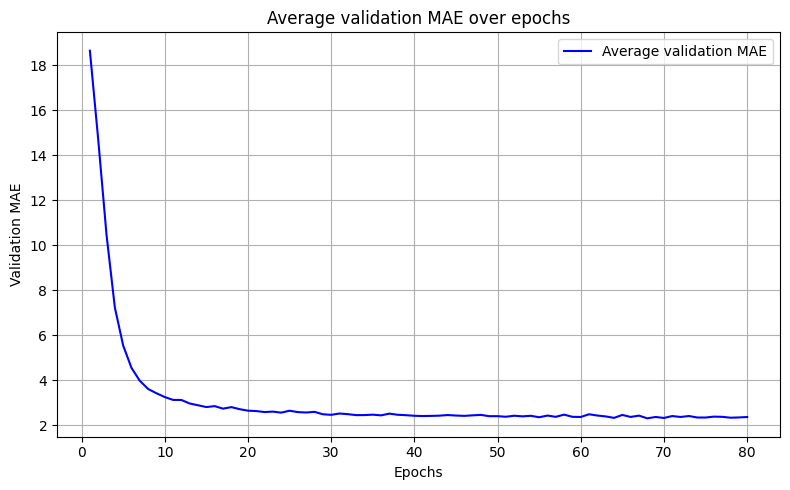

In [30]:
k = 4
num_val_samples = len(train_data) // k
num_epochs = 80
all_mae_histories = []

for i in range(k):
    print('processing fold #', i)

    # TODO: Tạo validation fold
    val_data = train_data[i * num_val_samples: (i + 1) * num_val_samples]
    val_targets = train_targets[i * num_val_samples: (i + 1) * num_val_samples]

    # TODO: Tạo partial train
    partial_train_data = np.concatenate(
        [train_data[:i * num_val_samples],
         train_data[(i + 1) * num_val_samples:]],
        axis=0
    )
    partial_train_targets = np.concatenate(
        [train_targets[:i * num_val_samples],
         train_targets[(i + 1) * num_val_samples:]],
        axis=0
    )

    # TODO: Build model mới
    model = build_model()

    # TODO: Train và lưu history
    history = model.fit(
        partial_train_data,
        partial_train_targets,
        validation_data=(val_data, val_targets),
        epochs=num_epochs,
        batch_size=16,
        verbose=0
    )

    # TODO: Lấy mae history của fold hiện tại và append vào all_mae_histories
    mae_history = history.history['val_mae']
    all_mae_histories.append(mae_history)

# TODO: Tính average_mae_history
average_mae_history = [
    np.mean([x[i] for x in all_mae_histories]) for i in range(num_epochs)
]

# TODO: Vẽ average_mae_history
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(average_mae_history) + 1), average_mae_history, 'b', label='Average validation MAE')
plt.title('Average validation MAE over epochs')
plt.xlabel('Epochs')
plt.ylabel('Validation MAE')
plt.legend()
plt.tight_layout()
plt.grid(True)
plt.show()


## Bài 4.6 - Huấn luyện mô hình cuối cùng và đánh giá trên test set

**Yêu cầu:**
- Tạo mô hình mới.
- Train với số epoch hợp lý dựa trên đường cong MAE vừa vẽ.
- Đánh giá trên test set.

In [31]:
# TODO: Tạo final_model
final_model = build_model()

# TODO: Train final_model trên toàn bộ train_data, train_targets
final_model.fit(
    train_data, 
    train_targets, 
    epochs=60, 
    batch_size=16, 
    verbose=0
)

# TODO: Đánh giá trên test_data, test_targets
test_mse_score, test_mae_score = final_model.evaluate(test_data, test_targets, verbose=0)

# TODO: In kết quả test_mse_score và test_mae_score
print("Test MSE Score:", test_mse_score)
print("Test MAE Score:", test_mae_score)


/home/zhu/micromamba/lib/python3.12/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Test MSE Score: 19.026464462280273
Test MAE Score: 2.8043673038482666


## Câu hỏi thảo luận - Boston Housing

1. Vì sao bài toán này không dùng `accuracy`?
    
    Accuracy không phải là một metric phù hợp cho bài toán hồi quy, vì nó đo lường tỷ lệ dự đoán chính xác trong các bài toán phân loại. Trong khi đó, bài toán hồi quy yêu cầu đo lường mức độ sai số giữa giá trị dự đoán và giá trị thực tế, do đó sử dụng các metric như MSE (Mean Squared Error) hoặc MAE (Mean Absolute Error) sẽ phù hợp hơn để đánh giá hiệu suất của mô hình hồi quy.

2. Vì sao phải chuẩn hóa dữ liệu theo từng đặc trưng?
    
    Chuẩn hóa dữ liệu theo từng đặc trưng giúp đảm bảo rằng tất cả các đặc trưng có cùng một khoảng giá trị, điều này giúp mô hình học nhanh hơn và ổn định hơn. Nếu không chuẩn hóa, các đặc trưng có giá trị lớn sẽ ảnh hưởng mạnh đến quá trình học của mô hình.

3. Vì sao khi dữ liệu ít, K-fold validation đáng tin cậy hơn một lần train/validation split?
    
    K-fold validation đáng tin cậy hơn một lần train/validation split khi dữ liệu ít vì nó sử dụng toàn bộ dữ liệu để huấn luyện và đánh giá mô hình. Mỗi mẫu dữ liệu sẽ được sử dụng làm validation set một lần, giúp giảm thiểu sự phụ thuộc vào cách chia dữ liệu ban đầu và cung cấp một ước lượng hiệu suất tổng thể chính xác hơn.

4. Vì sao lớp cuối của mô hình hồi quy không dùng `sigmoid` hay `softmax`?
    
    Vì bài toán này là hồi quy, lớp cuối cần trả về một giá trị liên tục thay vì một xác suất phân loại. Do đó, lớp cuối thường sử dụng một hàm kích hoạt tuyến tính (hoặc không có hàm kích hoạt) để cho phép mô hình dự đoán bất kỳ giá trị nào trong phạm vi của dữ liệu mục tiêu, thay vì giới hạn trong khoảng [0, 1] như `sigmoid` hoặc phân phối xác suất như `softmax`.

# PHẦN 5 - TỔNG KẾT

## Bài tập tự đánh giá

Hoàn thành bảng sau vào vở hoặc markdown cell mới:

| Bài toán | Dạng đầu ra | Activation lớp cuối | Loss | Metric |
|---|---|---|---|---|
| IMDB | ? | ? | ? | ? |
| Iris | ? | ? | ? | ? |
| Reuters | ? | ? | ? | ? |
| Boston Housing | ? | ? | ? | ? |

## Câu hỏi vận dụng

1. Khi nào nên dùng `binary_crossentropy`?

    'binary_crossentropy' được sử dụng khi đang giải quyết một bài toán phân loại nhị phân, tức là khi chỉ có hai lớp (ví dụ: 0 và 1, hoặc "có" và "không"). Nó đo lường sự khác biệt giữa hai phân phối xác suất - phân phối thực tế (nhãn) và phân phối dự đoán (đầu ra của mô hình). Nếu bạn đang làm việc với một bài toán phân loại đa lớp, bạn sẽ sử dụng 'categorical_crossentropy' thay vì 'binary_crossentropy'.

2. Khi nào nên dùng `categorical_crossentropy`?

    'categorical_crossentropy' được sử dụng khi đang giải quyết một bài toán phân loại đa lớp, tức là khi có nhiều hơn hai lớp (ví dụ: 0, 1, và 2). Nó đo lường sự khác biệt giữa phân phối thực tế (nhãn) và phân phối dự đoán (đầu ra của mô hình).

3. Khi nào nên dùng `mse` và `mae`?

    'MSE' (Mean Squared Error) và 'MAE' (Mean Absolute Error) được sử dụng trong các bài toán hồi quy, nơi mục tiêu là dự đoán một giá trị liên tục. 
    
    MSE đo lường bình phương của sai số giữa giá trị thực tế và giá trị dự đoán, trong khi MAE đo lường giá trị tuyệt đối của sai số. MSE thường nhạy cảm hơn với các ngoại lệ so với MAE.

4. Validation loss và training loss khác nhau thế nào về ý nghĩa?

    Validation loss đo lường hiệu suất của mô hình trên một tập dữ liệu mà mô hình chưa từng thấy trong quá trình huấn luyện (validation set). Nó giúp đánh giá khả năng tổng quát hóa của mô hình. 

    Training loss đo lường hiệu suất của mô hình trên tập dữ liệu mà nó đã được huấn luyện (training set). Nếu training loss thấp nhưng validation loss cao, điều đó có thể cho thấy rằng mô hình đang bị overfitting, tức là nó học quá kỹ các mẫu trong training set và không thể tổng quát hóa tốt trên dữ liệu mới.

5. Một mô hình có train accuracy rất cao nhưng val accuracy thấp cho biết điều gì?

    Một mô hình có train accuracy rất cao nhưng val accuracy thấp thường cho thấy rằng mô hình đang bị overfitting. Điều này có nghĩa là mô hình đã học quá kỹ các mẫu trong training set, bao gồm cả nhiễu và các đặc điểm không quan trọng, dẫn đến hiệu suất kém trên dữ liệu mới (validation set). Mô hình này không thể tổng quát hóa tốt và sẽ gặp khó khăn khi dự đoán chính xác trên dữ liệu mà nó chưa từng thấy trước đó.



| Bài toán | Dạng đầu ra | Activation lớp cuối | Loss | Metric |
|---|---|---|---|---|
| IMDB | Nhị phân (0 hoặc 1) | Sigmoid | Binary Crossentropy | Accuracy |
| Iris | Đa lớp (3 lớp) | Softmax | Categorical Crossentropy | Accuracy |
| Reuters | Đa lớp (46 lớp) | Softmax | Categorical Crossentropy | Accuracy |
| Boston Housing | Tuyến tính | Linear Regression | Mean Squared Error | Mean Absolute Error |